    project team
    Data Project and Hackaton 3
    _course instructor_

In [1]:
from utils.data import *

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import pyarrow.parquet as pq
from tqdm.auto import tqdm
tqdm.pandas()

os.makedirs("data", exist_ok=True)

RANDOM_SEED = 21
# 35

from utils.splitting import *

# path to the Parquet files folder
CLEANED_DATA_PATH = "data/cleaned_parquet"
SPLIT_DATA_PATH = "data/split"

# utils paths
ID_REGISTRY_PATH = "data/ids_registry.parquet"

# splitting parameters
RANGE_YEARS_FOR_SPLITTING = range(1971, 2025) 
N_TRAIN_PAPERS = 500_000
N_VALIDATION_PAPERS = 300_000  
N_TEST_PAPERS = 300_000


densitz of the graph, how connected the graph is

# B - Split datataset

We consider only papers published between 1971 and 2024 (included). Before 1971 the number of publications per year is very low, while after 2024 not enough papers are available.

The dataset is split into train, validation and test sets using a year‑weighted strategy. The number of papers selected per year is proportional to the actual publication papers of that year.

This approach preserves the real temporal distribution of scientific research and avoids bias. Earlier years are not over‑represented, and more recent years are not under‑sampled, ensuring a more realistic and representative training dataset.

Key features of this implementation:
Shared Logic: The get_year_color function is defined internally to ensure consistent coloring between the weight bar and the paper subplots.

sharex=True: In the 'papers' subplot mode, all three plots share the same X-axis. This makes it visually obvious that the data is partitioned: the Blue bars stop where the Yellow bars begin, and so on.

Automatic Alignment: For the subplots, the code iterates through the entire RANGE_YEARS_FOR_SPLITTING. This ensures that even if a set (like 'Test') only has data for 2020-2024, the plot doesn't "stretch" those bars; it places them correctly at the end of the timeline.

Flexibility: Calling the function without arguments will generate both views, which is useful for a final inspection of your data splitting strategy.

## 1. Downsample from Cleaned Data
- rescale the dataset in a given year range on which focus the study
- balance maintaining the year distribution
- avoid overlapping years between sets
- avoid less than 3 years in a single set to be meaningfull and representative

### 1.1 Identify Years Range
- import the ids_registry to count the publication per year
- define weights to downsample a balanced dataset

In [49]:
try:
    print(f'Read and import file IDs raw data from: {ID_REGISTRY_PATH}')
    ids_registry = pd.read_parquet(ID_REGISTRY_PATH)
    print(f"Found {len(ids_registry)} unique IDs.")
except Exception as e:
    print(f"Error reading the file: {e}")

Read and import file IDs raw data from: data/ids_registry.parquet
Found 6729828 unique IDs.


In [50]:
# years publication 
year_counts = ids_registry['year'].value_counts().sort_index()
# filter for interested years
year_counts = year_counts.loc[year_counts.index.isin(RANGE_YEARS_FOR_SPLITTING)]
# total number of papers available in the interested years
total_available_papers = year_counts.sum()
# weights based on distr of papers per year,
# select more papers from the years with more publications and less from the years with less publications
year_weights = year_counts / total_available_papers

# target total papers
N_TOT = N_TRAIN_PAPERS + N_VALIDATION_PAPERS + N_TEST_PAPERS

### 1.2 Assign Years to Sets in a Chronological Order
- each set assigned to a set of years, at least 3 years to be representative

In [51]:
# cumulative sum to find where the thresholds fall
cumulative_weights = year_weights.cumsum()

# target percentages
train_pct = N_TRAIN_PAPERS / N_TOT
val_pct = N_VALIDATION_PAPERS / N_TOT

# find split years
train_end_year = cumulative_weights[cumulative_weights <= train_pct].index[-1]
val_end_year = cumulative_weights[cumulative_weights <= (train_pct + val_pct)].index[-1]

# define ranges
train_years = [y for y in RANGE_YEARS_FOR_SPLITTING if y <= train_end_year]
val_years = [y for y in RANGE_YEARS_FOR_SPLITTING if train_end_year < y <= val_end_year]
test_years = [y for y in RANGE_YEARS_FOR_SPLITTING if y > val_end_year]
# sanity check that we have at least N years in each set, otherwise we need to adjust the logic
min_years = 10

if not (check_N_years(test_years, "Test", min_years) and check_N_years(val_years, "Validation", min_years) and check_N_years(train_years, "Training", min_years)):
    # Fallback logic: Select last 3 for Test, previous 3 for Val, rest for Train
    all_years = sorted(list(RANGE_YEARS_FOR_SPLITTING))
    test_years = all_years[-min_years:]
    val_years = all_years[-(2 * min_years):-min_years]
    train_years = all_years[:- (2 * min_years)]
    print(f"Manual override: Train({min(train_years)}-{max(train_years)}), Val({min(val_years)}-{max(val_years)}), Test({min(test_years)}-{max(test_years)})")

Manual override: Train(1971-2004), Val(2005-2014), Test(2015-2024)


### 1.3 Assign papers per year
- assign how many papers to take from each year
- splitting avoiding data leakage, then they wouldn't be in the same time range

In [52]:
n_tr_per_year = get_papers_per_year(N_TRAIN_PAPERS, train_years, year_weights)
n_val_per_year = get_papers_per_year(N_VALIDATION_PAPERS, val_years, year_weights)
n_test_per_year = get_papers_per_year(N_TEST_PAPERS, test_years, year_weights)


print(f"Train Years(num of papers {n_tr_per_year.sum()}): {min(train_years)} - {max(train_years)}")
print(f"Val Years(num of papers {n_val_per_year.sum()}): {min(val_years)} - {max(val_years)}")
print(f"Test Years(num of papers {n_test_per_year.sum()}): {min(test_years)} - {max(test_years)}")

Train Years(num of papers 500000): 1971 - 2004
Val Years(num of papers 300000): 2005 - 2014
Test Years(num of papers 300000): 2015 - 2024


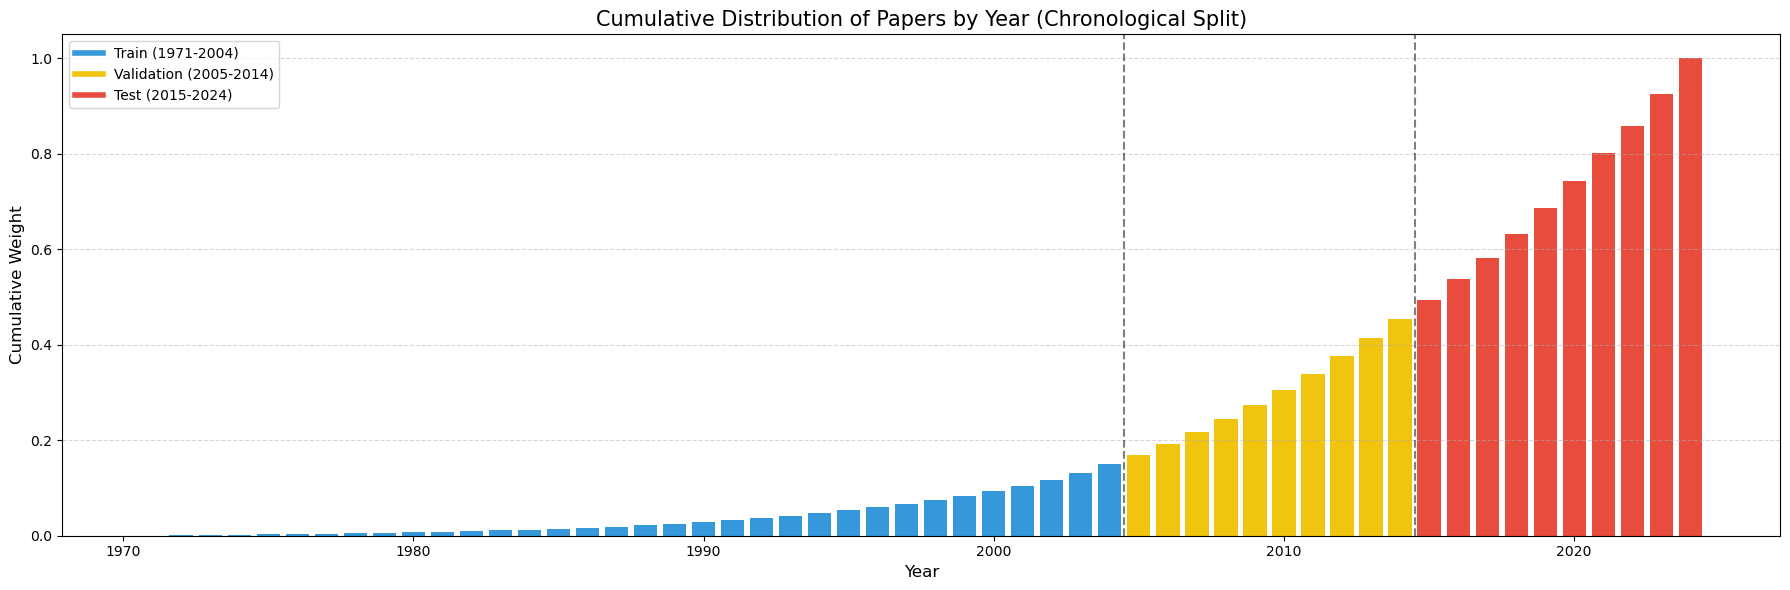

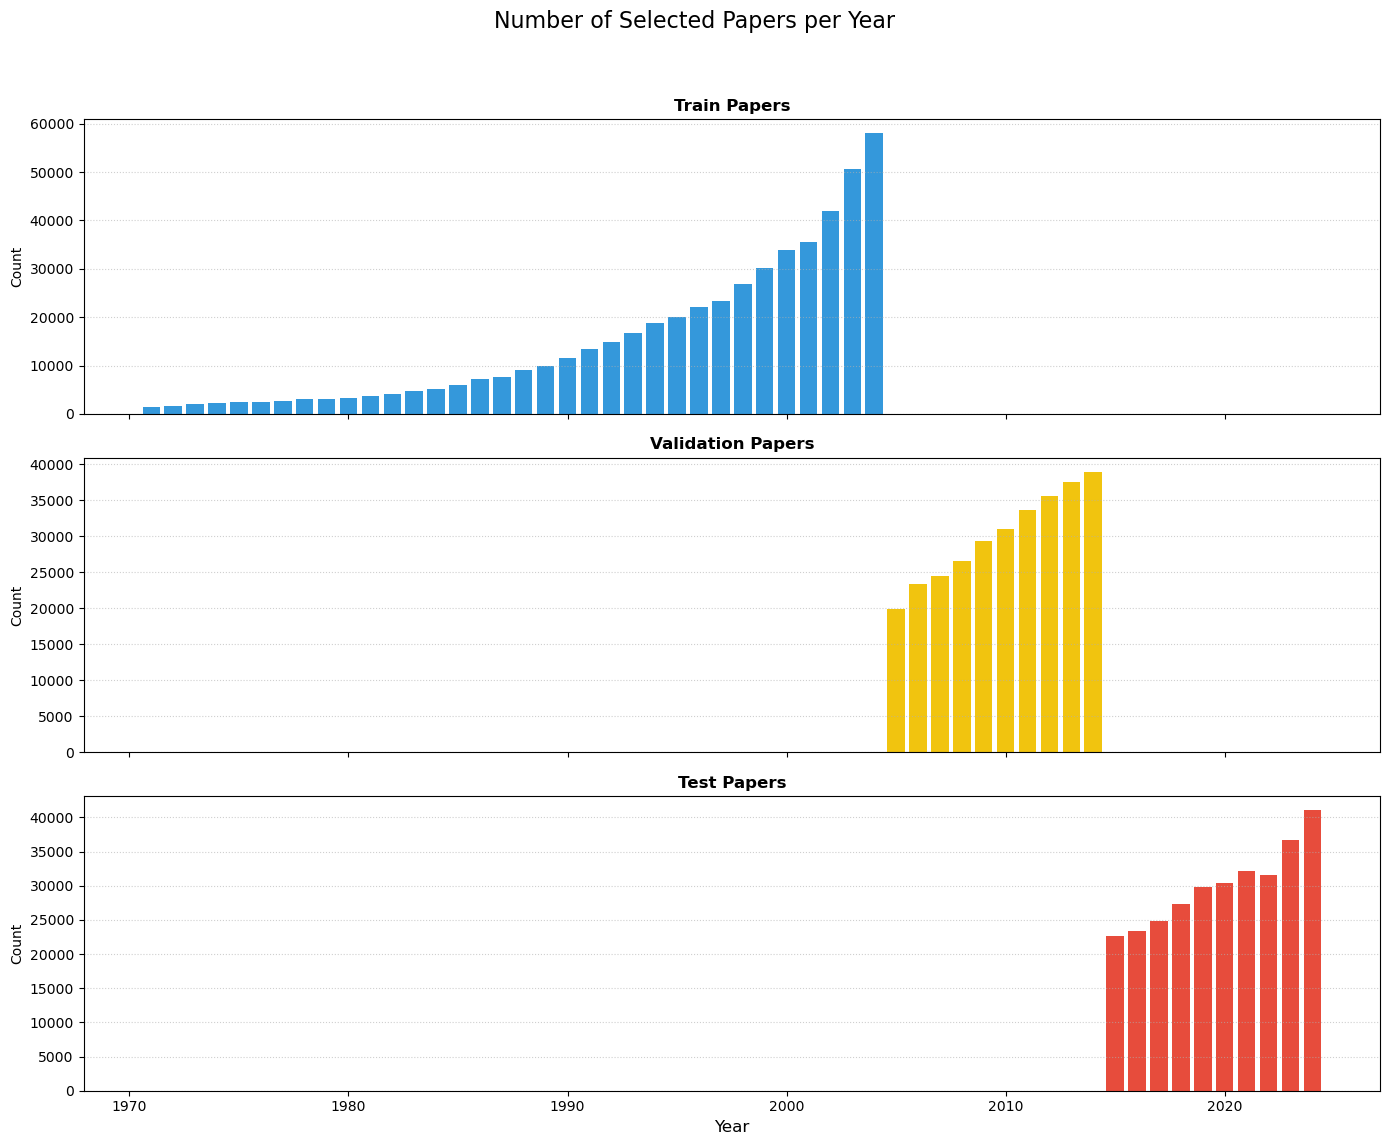

In [53]:
plot_split_distribution(cumulative_weights, (train_years, val_years, test_years), (n_tr_per_year, n_val_per_year, n_test_per_year), range_years=RANGE_YEARS_FOR_SPLITTING,mode=None)

## 2. Split dataset
- divide in train, validation and test set

In [54]:
train_list, val_list, test_list = [], [], []

for y in tqdm(train_years, desc="Sampling Train"):
    train_list.append(sample_from_year(y, n_tr_per_year[y], cleaned_data_path=CLEANED_DATA_PATH, random_state=RANDOM_SEED))

for y in tqdm(val_years, desc="Sampling Validation"):
    val_list.append(sample_from_year(y, n_val_per_year[y], cleaned_data_path=CLEANED_DATA_PATH, random_state=RANDOM_SEED))

for y in tqdm(test_years, desc="Sampling Test"):
    test_list.append(sample_from_year(y, n_test_per_year[y], cleaned_data_path=CLEANED_DATA_PATH, random_state=RANDOM_SEED))

# final concatenation
train_chunk = pd.concat(train_list, ignore_index=True)
val_chunk = pd.concat(val_list, ignore_index=True)
test_chunk = pd.concat(test_list, ignore_index=True)

# final global shuffle to mix the years within each set
train_chunk = train_chunk.sample(frac=1).reset_index(drop=True)
val_chunk = val_chunk.sample(frac=1).reset_index(drop=True)
test_chunk = test_chunk.sample(frac=1).reset_index(drop=True)

Sampling Train:   0%|          | 0/34 [00:00<?, ?it/s]

Sampling Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Sampling Test:   0%|          | 0/10 [00:00<?, ?it/s]

In [55]:
print(f"Final Train set: {len(train_chunk)} papers")
display(train_chunk.head(3))

print(f"Final Validation set: {len(val_chunk)} papers")
display(val_chunk.head(3)) 

print(f"Final Test set: {len(test_chunk)} papers")
display(test_chunk.head(3))

Final Train set: 500000 papers


,id,title,lang,doc_type,venue,doi,abstract,year,n_citation,references,keywords,url,authors
0,53e9baf1b7602d9704721933,The Persona Effect: How Substantial Is It?,NaN,conference,HCI '98: Proceedings of HCI on People and Comp...,10.1007/978-1-4471-3605-7_4,Personification of interface agents has been s...,1998.0,208.0,"[539087e720f70186a0d68025, 53e9b895b7602d97044...","[personified interface agents, persona effect,...","[db/conf/bcshci/bcshci1998.html#MulkenAM98, h...","[{'id': '53f44f90dabfaedd74e12e9f', 'name': 'S..."
1,53e9ab4fb7602d97034e09a1,An Endogenous Segmentation Mode Choice Model w...,en,journal,Transportation Science,10.1287/trsc.31.1.34,This article uses an endogenous segmentation a...,1997.0,328.0,[],None,[https://www.semanticscholar.org/paper/c93493a...,"[{'id': '5405a69cdabfae92b41ef3ce', 'name': 'C..."
2,53e9bba7b7602d97047eda8a,A Sequence Building Approach to Pattern Discov...,en,conference,FLAIRS Conference,NaN,The goal of the research being reported is the...,1998.0,26.0,"[53e9ad72b7602d9703763be7, 53e9ab7eb7602d97035...","[Medical Data, Pattern Discovery, Sequence Bui...",[http://www.aaai.org/Library/FLAIRS/1998/flair...,"[{'id': '53f46bacdabfaeb22f553477', 'name': 'J..."


Final Validation set: 300000 papers


,id,title,lang,doc_type,venue,doi,abstract,year,n_citation,references,keywords,url,authors
0,558bf4490cf2e30013db3a0d,"The Software Development Process of FLASH, a M...",en,conference,Computational Science and Engineering,10.1109/secse.2013.6615093,The FLASH code has evolved into a modular and ...,2013.0,34.0,[5390a72220f70186a0e89479],"[FLASH code, community code, software evolutio...","[https://doi.org/10.1109/SECSE.2013.6615093, ...","[{'id': '53f47334dabfaefedbba145e', 'name': 'A..."
1,55a47b4a65ce31bc877ca31f,Coverage Assessment and Target Tracking in 3D ...,en,journal,Sensors,10.3390/s111009904,Recent advances in integrated electronic devic...,2011.0,13.0,"[5390975920f70186a0dfe00a, 599c77b7601a182cd25...","[wireless sensor networks, coverage holes, 3D ...","[https://doi.org/10.3390/s111009904, https://...","[{'id': '53f43169dabfaee1c0a67e42', 'name': 'N..."
2,53e9b89bb7602d97044729af,RAS Celebrations and Award Winners [society News],en,journal,IEEE Robotics & Automation Magazine,10.1109/mra.2012.2206649,IEEE International Conference on Robotics and ...,2012.0,0.0,[],None,[https://ieeexplore.ieee.org/document/6299178],"[{'id': '53f465b2dabfaeee22a50e47', 'name': 'R..."


Final Test set: 300000 papers


,id,title,lang,doc_type,venue,doi,abstract,year,n_citation,references,keywords,url,authors
0,61949dc5e1ef29355221cf56,Muscle Artifact Removal Toward Mobile SSVEP-Ba...,en,journal,IEEE Transactions on Instrumentation and Measu...,10.1109/tim.2021.3085944,Steady-state visual evoked potential (SSVEP) s...,2021.0,26.0,"[53e9b93eb7602d970452962f, 5a73cb9817c44a0b303...","[Electroencephalography (EEG), electromyogram ...",None,"[{'id': '542df425dabfae11fc4b5c53', 'name': 'A..."
1,605b16f291e01123a133b01a,Team Alexa at Authorship Identification of SOu...,NaN,conference,FIRE,NaN,"In this paper, we discuss our team’s effort on...",2020.0,2.0,[5390aefc20f70186a0ece078],"[authorship identification, source code, team ...",[https://www.semanticscholar.org/paper/0cc0e96...,"[{'id': '64bf2e47e5e366350d3ef65c', 'name': 'M..."
2,5ee3526a91e011cb3bff72d7,Variational Optimization for the Submodular Ma...,en,journal,arXivorg,NaN,We examine the submodular maximum coverage pro...,2020.0,18.0,"[57aa28de0a3ac518da9896e8, 53e9990db7602d97021...",None,[http://arxiv.org/abs/2006.05583],"[{'id': '562d065545cedb3398d317bb', 'name': 'J..."


## 3. Verify Valid Connectivity
Using graph, verify how well the sets are connected within each other


--- Starting Connectivity Analysis for: Training Set ---
[Training Set] Cleaning and exploding references...
[Training Set] Building the network graph...


Adding edges for Training Set:   0%|          | 0/1081260 [00:00<?, ?it/s]

[Training Set] Identifying connected components...
------------------------------

Results for Training Set
	Total Papers (Nodes): 500000
	Total Clusters (Connected Groups): 153538
	Largest Cluster Size: 338189 papers (67.64%)
	Smallest Cluster Size: 1 papers (0.00%)

	Cluster Size Distribution (Frequency):
		- Clusters of size 1: 147705
		- Clusters of size 2: 4451
		- Clusters of size 3: 846
		- Clusters of size 4: 319
		- Clusters of size 5: 97
		- Clusters of size 6: 54
		- Clusters of size 7: 28
		- Clusters of size 8: 11
		- Clusters of size 9: 8
		- Clusters of size 10: 5
		- Clusters of size 11: 3
		- Clusters of size 12: 2
		- Clusters of size 13: 3
		- Clusters of size 14: 2
		- Clusters of size 16: 1
		- Clusters of size 17: 1
		- Clusters of size 18: 1
		- Clusters of size 338189: 1
[Training Set] Plotting cluster size distribution...


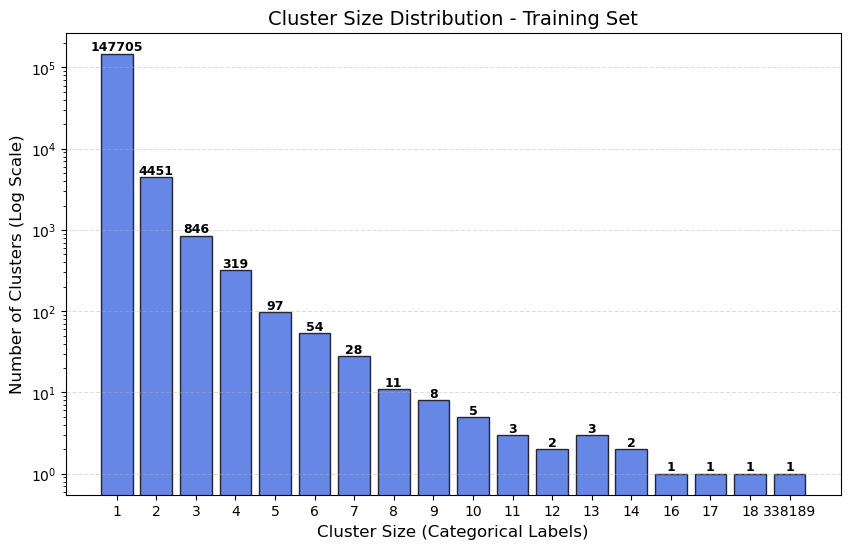


--- Starting Connectivity Analysis for: Validation Set ---
[Validation Set] Cleaning and exploding references...
[Validation Set] Building the network graph...


Adding edges for Validation Set:   0%|          | 0/195621 [00:00<?, ?it/s]

[Validation Set] Identifying connected components...
------------------------------

Results for Validation Set
	Total Papers (Nodes): 300000
	Total Clusters (Connected Groups): 161447
	Largest Cluster Size: 117134 papers (39.04%)
	Smallest Cluster Size: 1 papers (0.00%)

	Cluster Size Distribution (Frequency):
		- Clusters of size 1: 148149
		- Clusters of size 2: 9361
		- Clusters of size 3: 2244
		- Clusters of size 4: 801
		- Clusters of size 5: 386
		- Clusters of size 6: 195
		- Clusters of size 7: 104
		- Clusters of size 8: 59
		- Clusters of size 9: 63
		- Clusters of size 10: 23
		- Clusters of size 11: 12
		- Clusters of size 12: 15
		- Clusters of size 13: 8
		- Clusters of size 14: 5
		- Clusters of size 15: 4
		- Clusters of size 16: 1
		- Clusters of size 17: 2
		- Clusters of size 18: 1
		- Clusters of size 19: 1
		- Clusters of size 20: 2
		- Clusters of size 22: 2
		- Clusters of size 23: 1
		- Clusters of size 24: 1
		- Clusters of size 25: 1
		- Clusters of size 26:

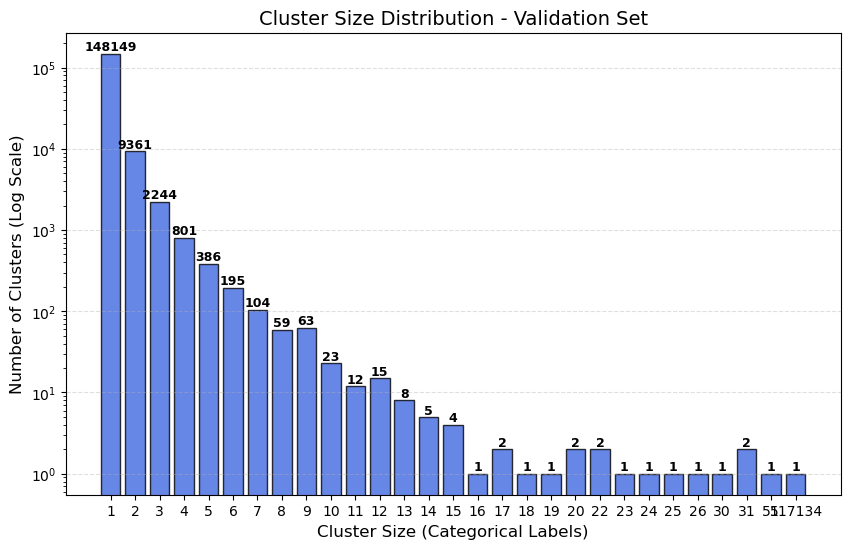


--- Starting Connectivity Analysis for: Test Set ---
[Test Set] Cleaning and exploding references...
[Test Set] Building the network graph...


Adding edges for Test Set:   0%|          | 0/198191 [00:00<?, ?it/s]

[Test Set] Identifying connected components...
------------------------------

Results for Test Set
	Total Papers (Nodes): 300000
	Total Clusters (Connected Groups): 168849
	Largest Cluster Size: 112508 papers (37.50%)
	Smallest Cluster Size: 1 papers (0.00%)

	Cluster Size Distribution (Frequency):
		- Clusters of size 1: 156923
		- Clusters of size 2: 8560
		- Clusters of size 3: 1968
		- Clusters of size 4: 687
		- Clusters of size 5: 318
		- Clusters of size 6: 150
		- Clusters of size 7: 81
		- Clusters of size 8: 48
		- Clusters of size 9: 30
		- Clusters of size 10: 22
		- Clusters of size 11: 18
		- Clusters of size 12: 12
		- Clusters of size 13: 7
		- Clusters of size 14: 6
		- Clusters of size 15: 5
		- Clusters of size 16: 1
		- Clusters of size 17: 2
		- Clusters of size 18: 3
		- Clusters of size 19: 3
		- Clusters of size 20: 2
		- Clusters of size 22: 1
		- Clusters of size 51: 1
		- Clusters of size 112508: 1
[Test Set] Plotting cluster size distribution...


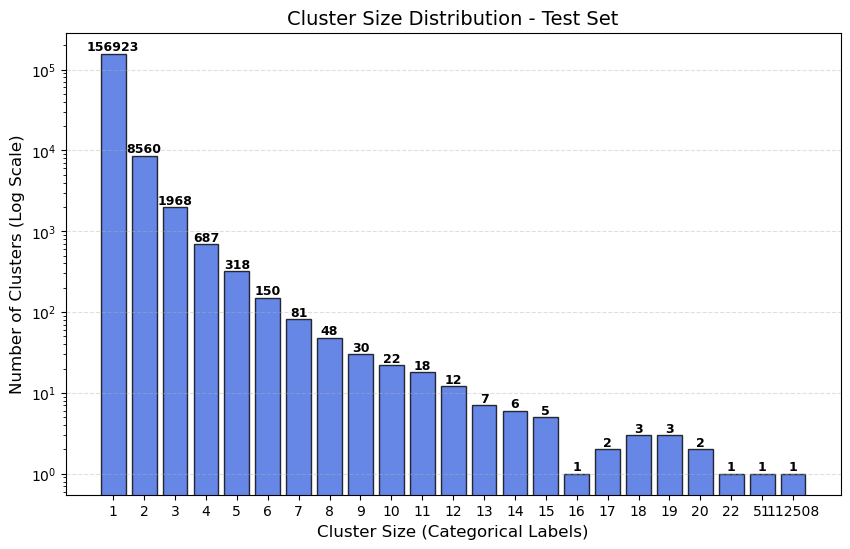

In [56]:
results_train = analyze_set_connectivity(train_chunk, "Training Set", show_graph=False, show_distribution=True)
results_val = analyze_set_connectivity(val_chunk, "Validation Set", show_graph=False, show_distribution=True)
results_test = analyze_set_connectivity(test_chunk, "Test Set", show_graph=False, show_distribution=True)

## 4. Export splitted data

In [57]:
if not os.path.exists(SPLIT_DATA_PATH):
     os.makedirs(SPLIT_DATA_PATH)
     
train_chunk.to_parquet(os.path.join(SPLIT_DATA_PATH, "train.parquet"))
val_chunk.to_parquet(os.path.join(SPLIT_DATA_PATH, "validation.parquet"))  
test_chunk.to_parquet(os.path.join(SPLIT_DATA_PATH, "test.parquet"))